In [ ]:
# 1. Compréhension du problème
Une entreprise de télécommunication souhaite comprendre pourquoi certains clients quittent ses services.
L objectif est d analyser les caractéristiques des clients et de construire un modèle capable de prédire
la probabilité de départ des clients.

Q : Quels sont les facteurs qui influencent le départ des clients et comment peut-on identifier les clients
présentant une forte probabilité de quitter l entreprise ?

In [12]:
# 2. COMPRÉHENSION DES DONNÉES

import pandas as pd

# 1. Charger le dataset
df = pd.read_csv("TelcoCustomerChurn.csv")

# 2. Dimensions du dataset
print("Dimensions :", df.shape)
print("Nombre de clients :", df.shape[0])
print("Nombre de variables :", df.shape[1])

# 3. Aperçu des données
print("\nAperçu des données :")
display(df.head())

# 4. Noms des variables
print("\nNoms des variables :")
print(df.columns)

# 5. Informations générales
print("\nInformations générales :")
df.info()

Dimensions : (7043, 50)
Nombre de clients : 7043
Nombre de variables : 50

Aperçu des données :


,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,...,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges



Noms des variables :
Index(['CustomerID', 'Gender', 'Age', 'Under30', 'SeniorCitizen', 'Married',
       'Dependents', 'NumberofDependents', 'Country', 'State', 'City',
       'ZipCode', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'ReferredaFriend', 'Number_of_Referrals', 'TenureinMonths', 'Offer',
       'PhoneService', 'AvgMonthlyLongDistanceCharges', 'MultipleLines',
       'InternetService', 'InternetType', 'AvgMonthlyGBDownload',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtectionPlan',
       'PremiumTechSupport', 'StreamingTV', 'StreamingMovies',
       'StreamingMusic', 'UnlimitedData', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharge', 'TotalCharges', 'TotalRefunds',
       'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'TotalRevenue',
       'SatisfactionScore', 'CustomerStatus', 'ChurnLabel', 'ChurnScore',
       'CLTV', 'ChurnCategory', 'ChurnReason'],
      dtype='object')

Informations générales :
<class 'pandas.core.frame.

In [13]:
# DATA CLEANING - NETTOYAGE DES DONNÉES

# 1. Vérifier les doublons
print("Nombre de doublons :", df.duplicated().sum())

# Supprimer les doublons
df = df.drop_duplicates()

print("Doublons après suppression :", df.duplicated().sum())


# 2. Vérifier les valeurs manquantes
print("\nValeurs manquantes avant traitement :")
print(df.isnull().sum())


# 3. Traiter les valeurs manquantes

df["Offer"] = df["Offer"].fillna("No Offer")

df["InternetType"] = df["InternetType"].fillna("No Internet")

df["ChurnCategory"] = df["ChurnCategory"].fillna("Not Churned")

df["ChurnReason"] = df["ChurnReason"].fillna("Not Churned")

# Traitement des valeurs manquantes :
# Les valeurs manquantes sont traitées selon la signification de chaque variable.
# Pour les variables catégorielles dont l'absence représente une situation réelle,
# une catégorie explicite est créée (ex. "No Offer", "No Internet", "Not Churned")
# afin de conserver l'information sans introduire artificiellement la modalité la plus fréquente

# 4. Vérifier les valeurs manquantes après traitement
print("\nValeurs manquantes après traitement :")
print(df.isnull().sum())

# 3. Vérification des noms des colonnes

print("Noms des colonnes :")
print(df.columns.tolist())

# 4) Nettoyage des variables catégorielles
categorical_columns = df.select_dtypes(
    include="object"
).columns
for col in categorical_columns:
    df[col] = df[col].str.strip()
spaces = {}
for col in categorical_columns:
    count = df[col].str.contains(
        r'^\s|\s$',
        regex=True
    ).sum()
    
    if count > 0:
        spaces[col] = count

print("\n🔎 Espaces inutiles détectés :")
if len(spaces) == 0:
    print("✅ Aucun espace inutile trouvé")
else:
    display(
        pd.DataFrame(
            spaces.items(),
            columns=["Colonne","Nombre"]
        )
    )

# 5) Suppression des colonnes inutiles
constant_columns = [
    col for col in df.columns
    if df[col].nunique() == 1
]

print("\n📌 Colonnes constantes détectées :")

display(
    pd.DataFrame(
        constant_columns,
        columns=["Colonnes"]
    )
)
columns_to_remove = [
    "CustomerID",
    "Country",
    "State",
    "Quarter",
    "City",
    "ZipCode",
    "Latitude",
    "Longitude",
    "Population"
]
df = df.drop(
    columns=columns_to_remove
)
print("\n✅ Colonnes supprimées :")
print(columns_to_remove)

#"ZipCode","Latitude","Longitude","Population"ces variables n'apportent pas d'information pertinente pour l'objectif du modèle
#ou qu'on souhaite éviter d'introduire une dimension géographique inutile.

print("\n📏 Dimensions après suppression :")
print(df.shape)

# 6) Vérification des valeurs incohérentes
print("\n🔎 Vérification des valeurs incohérentes :")
# Age
age_errors = df[
    (df["Age"] < 0) |
    (df["Age"] > 100)
]
print(
    "Âges incohérents :",
    len(age_errors)
)
# Durée d'abonnement
tenure_errors = df[
    df["TenureinMonths"] < 0
]
print(
    "Durées d'abonnement incohérentes :",
    len(tenure_errors)
)
# Valeurs financières négatives

financial_columns = [
    "MonthlyCharge",
    "TotalCharges",
    "TotalRefunds",
    "TotalExtraDataCharges",
    "TotalLongDistanceCharges",
    "TotalRevenue"
]
for col in financial_columns:
    
    errors = (df[col] < 0).sum()
    
    print(
        f"{col} négatif : {errors}"
    )

# 7) Détection des outliers avec la méthode IQR
# Détection et traitement des outliers :
# Les valeurs atypiques sont détectées à l'aide de la méthode IQR.
# Elles ne sont pas automatiquement supprimées, car un outlier n'est pas forcément
# une erreur. Après vérification de leur cohérence, les valeurs extrêmes mais plausibles
# sont conservées afin de préserver les informations utiles à la modélisation.
numeric_columns = df.select_dtypes(
    include=["int64","float64"]
).columns
outliers_summary = []
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()
    outliers_summary.append(
        [
            col,
            count,
            round((count/len(df))*100,2)
        ]
    )
outliers_df = pd.DataFrame(
    outliers_summary,
    columns=[
        "Variable",
        "Nombre_outliers",
        "Pourcentage"
    ]
)
print("\n📊 Résumé des outliers :")
display(outliers_df)

# 8) Vérification finale du dataset nettoyé
print("\n✅ Dataset final après nettoyage :")
print(df.shape)
print("\n📋 Colonnes finales :")
display(
    pd.DataFrame(
        df.columns,
        columns=["Variables"]
    )
)

Nombre de doublons : 0
Doublons après suppression : 0

Valeurs manquantes avant traitement :
CustomerID                          0
Gender                              0
Age                                 0
Under30                             0
SeniorCitizen                       0
Married                             0
Dependents                          0
NumberofDependents                  0
Country                             0
State                               0
City                                0
ZipCode                             0
Latitude                            0
Longitude                           0
Population                          0
Quarter                             0
ReferredaFriend                     0
Number_of_Referrals                 0
TenureinMonths                      0
Offer                            3877
PhoneService                        0
AvgMonthlyLongDistanceCharges       0
MultipleLines                       0
InternetService                  

,Colonnes
0,Country
1,State
2,Quarter



✅ Colonnes supprimées :
['CustomerID', 'Country', 'State', 'Quarter', 'City', 'ZipCode', 'Latitude', 'Longitude', 'Population']

📏 Dimensions après suppression :
(7043, 41)

🔎 Vérification des valeurs incohérentes :
Âges incohérents : 0
Durées d'abonnement incohérentes : 0
MonthlyCharge négatif : 0
TotalCharges négatif : 0
TotalRefunds négatif : 0
TotalExtraDataCharges négatif : 0
TotalLongDistanceCharges négatif : 0
TotalRevenue négatif : 0

📊 Résumé des outliers :


,Variable,Nombre_outliers,Pourcentage
0,Age,0,0.00
1,NumberofDependents,1627,23.10
2,Number_of_Referrals,676,9.60
3,TenureinMonths,0,0.00
4,AvgMonthlyLongDistanceCharges,0,0.00
5,AvgMonthlyGBDownload,362,5.14
6,MonthlyCharge,0,0.00
7,TotalCharges,0,0.00
8,TotalRefunds,525,7.45
9,TotalExtraDataCharges,728,10.34



✅ Dataset final après nettoyage :
(7043, 41)

📋 Colonnes finales :


,Variables
0,Gender
1,Age
2,Under30
3,SeniorCitizen
4,Married
5,Dependents
6,NumberofDependents
7,ReferredaFriend
8,Number_of_Referrals
9,TenureinMonths


📊 Distribution de la variable cible :


,Nombre de clients
ChurnLabel,
No,5174
Yes,1869



📈 Pourcentage des clients :


,Pourcentage (%)
ChurnLabel,
No,73.46
Yes,26.54


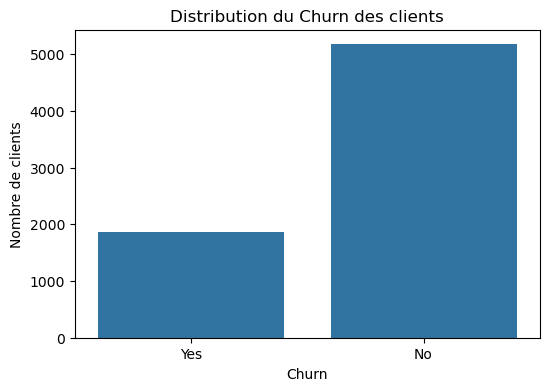

In [14]:
# EDA 1 - Analyse de la variable cible

import matplotlib.pyplot as plt
import seaborn as sns

# Distribution de ChurnLabel
print("📊 Distribution de la variable cible :")
display(
    df["ChurnLabel"]
    .value_counts()
    .to_frame("Nombre de clients")
)


# Pourcentage de churn
print("\n📈 Pourcentage des clients :")
display(
    (df["ChurnLabel"]
     .value_counts(normalize=True)*100)
    .round(2)
    .to_frame("Pourcentage (%)")
)


# Visualisation
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="ChurnLabel"
)
plt.title("Distribution du Churn des clients")
plt.xlabel("Churn")
plt.ylabel("Nombre de clients")
plt.show()

📋 Variables numériques analysées :


,Variables numériques
0,Age
1,NumberofDependents
2,Number_of_Referrals
3,TenureinMonths
4,AvgMonthlyLongDistanceCharges
5,AvgMonthlyGBDownload
6,MonthlyCharge
7,TotalCharges
8,TotalRefunds
9,TotalExtraDataCharges


📊 Analyse de la variable : Age

📌 Statistiques descriptives :


,Age
count,7043.000000
mean,46.509726
std,16.750352
min,19.000000
25%,32.000000
50%,46.000000
75%,60.000000
max,80.000000



📍 Médiane : 46.0

🔢 Nombre de valeurs uniques : 62


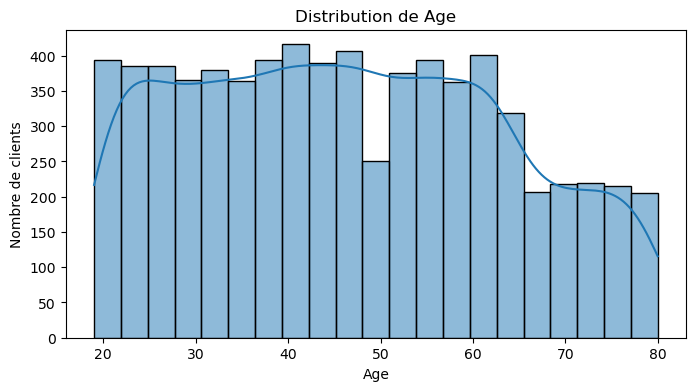

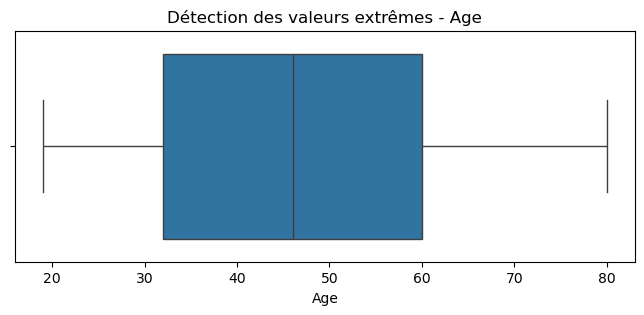

📊 Analyse de la variable : TenureinMonths

📌 Statistiques descriptives :


,TenureinMonths
count,7043.000000
mean,32.386767
std,24.542061
min,1.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000



📍 Médiane : 29.0

🔢 Nombre de valeurs uniques : 72


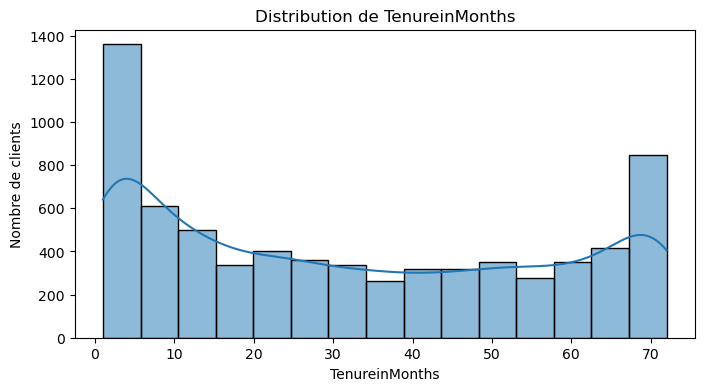

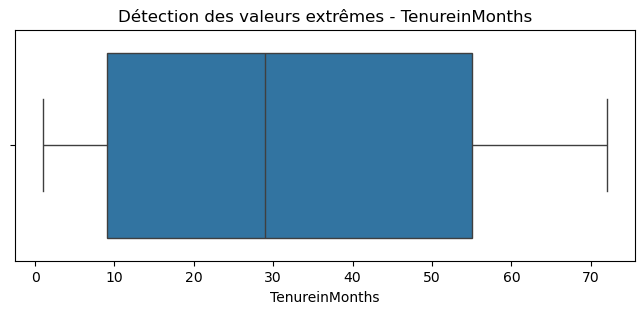

📊 Analyse de la variable : MonthlyCharge

📌 Statistiques descriptives :


,MonthlyCharge
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000



📍 Médiane : 70.35

🔢 Nombre de valeurs uniques : 1585


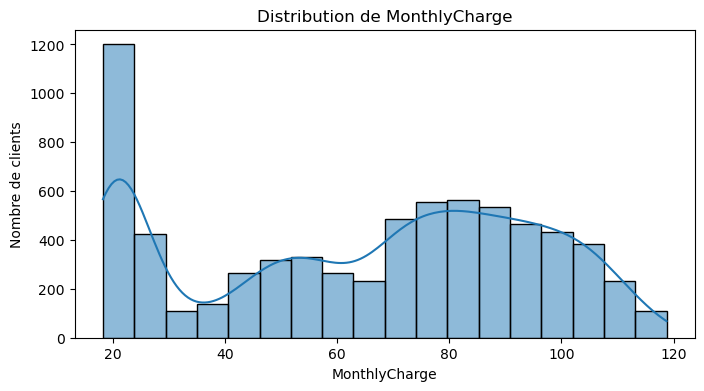

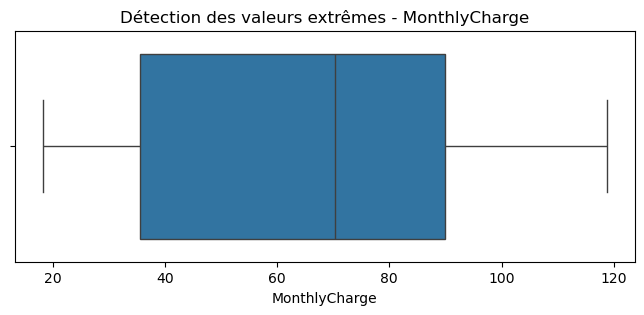

📊 Analyse de la variable : TotalCharges

📌 Statistiques descriptives :


,TotalCharges
count,7043.000000
mean,2280.381264
std,2266.220462
min,18.800000
25%,400.150000
50%,1394.550000
75%,3786.600000
max,8684.800000



📍 Médiane : 1394.55

🔢 Nombre de valeurs uniques : 6540


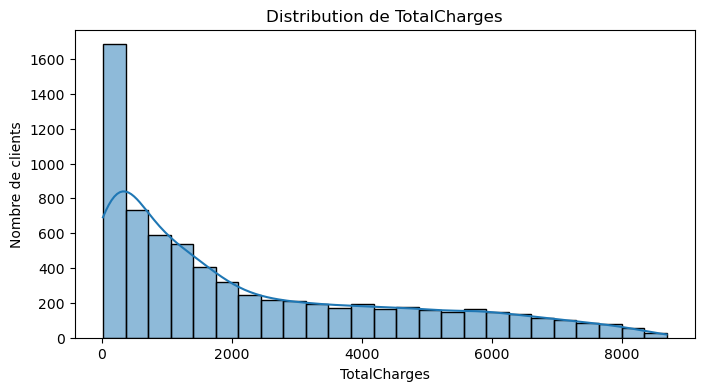

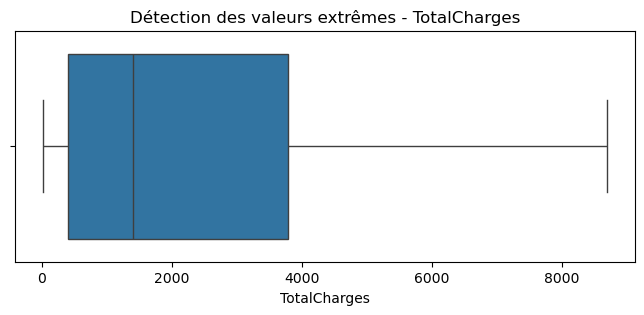

📊 Analyse de la variable : TotalRevenue

📌 Statistiques descriptives :


,TotalRevenue
count,7043.000000
mean,3034.379056
std,2865.204542
min,21.360000
25%,605.610000
50%,2108.640000
75%,4801.145000
max,11979.340000



📍 Médiane : 2108.64

🔢 Nombre de valeurs uniques : 6975


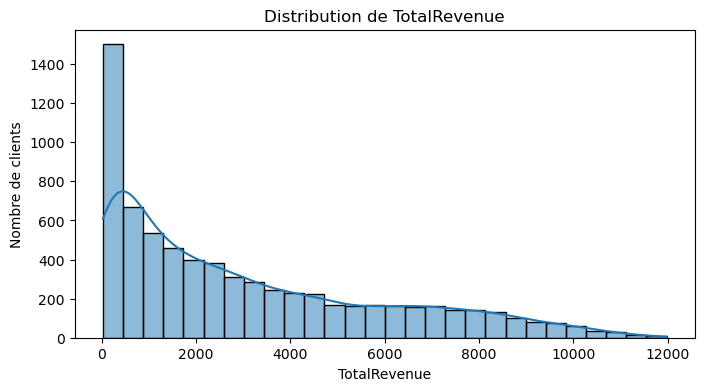

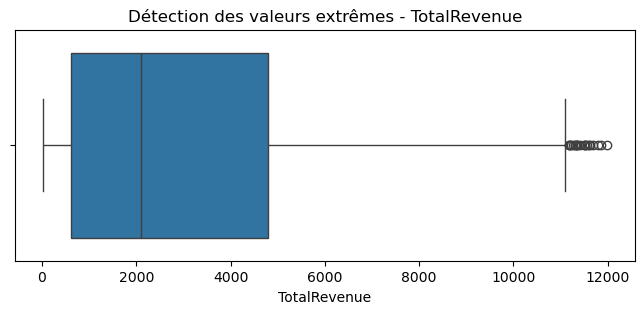

📊 Analyse de la variable : SatisfactionScore

📌 Statistiques descriptives :


,SatisfactionScore
count,7043.000000
mean,3.244924
std,1.201657
min,1.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,5.000000



📍 Médiane : 3.0

🔢 Nombre de valeurs uniques : 5


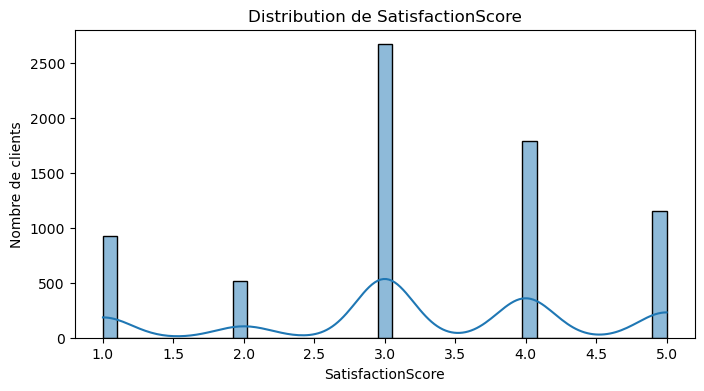

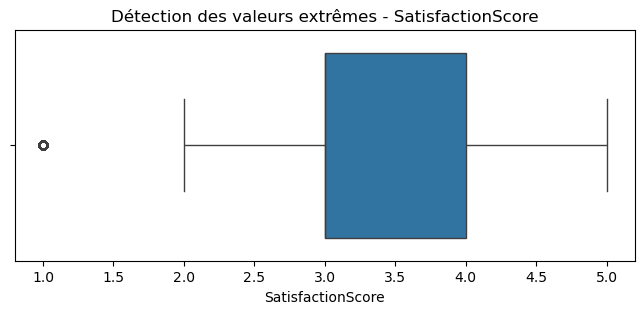

📊 Analyse de la variable : CLTV

📌 Statistiques descriptives :


,CLTV
count,7043.000000
mean,4400.295755
std,1183.057152
min,2003.000000
25%,3469.000000
50%,4527.000000
75%,5380.500000
max,6500.000000



📍 Médiane : 4527.0

🔢 Nombre de valeurs uniques : 3438


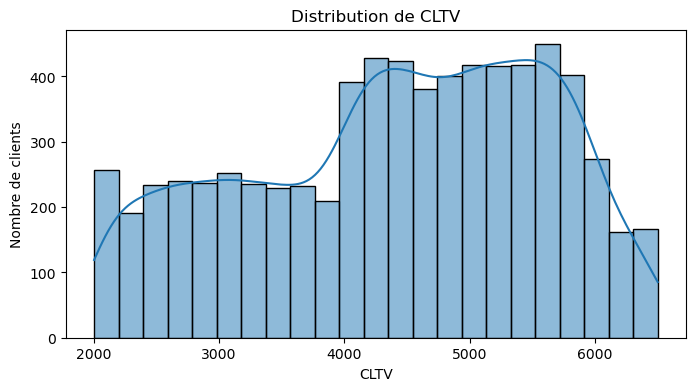

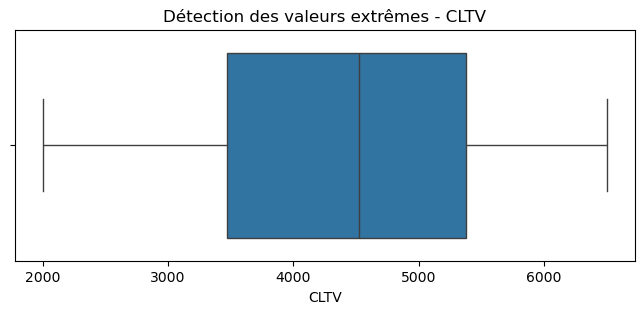

📊 Analyse de la variable : AvgMonthlyGBDownload

📌 Statistiques descriptives :


,AvgMonthlyGBDownload
count,7043.000000
mean,20.515405
std,20.418940
min,0.000000
25%,3.000000
50%,17.000000
75%,27.000000
max,85.000000



📍 Médiane : 17.0

🔢 Nombre de valeurs uniques : 50


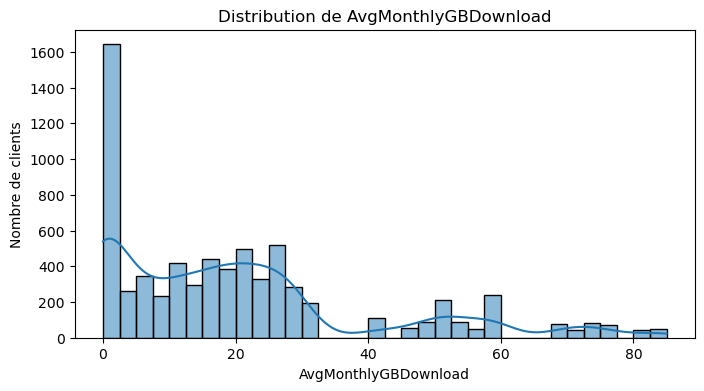

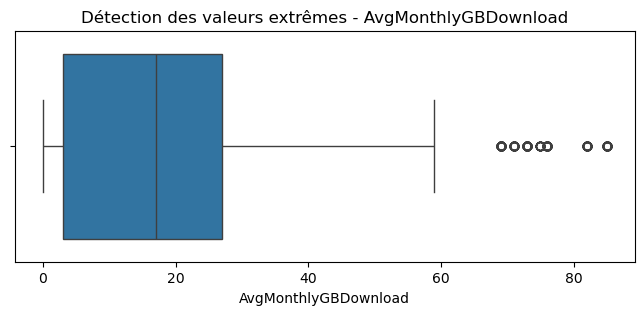

In [15]:
# EDA - Analyse univariée des variables numériques

import matplotlib.pyplot as plt
import seaborn as sns


# Sélection des variables numériques
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("📋 Variables numériques analysées :")
display(
    pd.DataFrame(numeric_columns, columns=["Variables numériques"])
)

# Fonction d'analyse d'une variable numérique
def analyse_variable_numerique(data, variable): 
    print("="*60)
    print(f"📊 Analyse de la variable : {variable}")
    print("="*60)

    # Statistiques descriptives
    print("\n📌 Statistiques descriptives :")
    display(
        data[variable].describe().to_frame()
    )
    
    # Médiane
    print("\n📍 Médiane :", data[variable].median())
    
    # Nombre de valeurs uniques
    print("\n🔢 Nombre de valeurs uniques :", 
          data[variable].nunique())
    
    # Histogramme
    plt.figure(figsize=(8,4))
    sns.histplot(
        data=data,
        x=variable,
        kde=True
    )
    plt.title(f"Distribution de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Nombre de clients")
    plt.show()

    # Boxplot
    plt.figure(figsize=(8,3))
    sns.boxplot(
        x=data[variable]
    )
    plt.title(f"Détection des valeurs extrêmes - {variable}")
    plt.show()

# Application sur les variables importantes
variables_importantes = [
    "Age",
    "TenureinMonths",
    "MonthlyCharge",
    "TotalCharges",
    "TotalRevenue",
    "SatisfactionScore",
    "CLTV",
    "AvgMonthlyGBDownload"
]

for var in variables_importantes:
    analyse_variable_numerique(df, var)

📋 Variables catégorielles analysées :


,Variables catégorielles
0,Gender
1,Under30
2,SeniorCitizen
3,Married
4,Dependents
5,ReferredaFriend
6,Offer
7,PhoneService
8,MultipleLines
9,InternetService


📊 Analyse de la variable : Gender

🔢 Nombre de catégories : 2

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
Gender,,
Male,3555,50.48
Female,3488,49.52


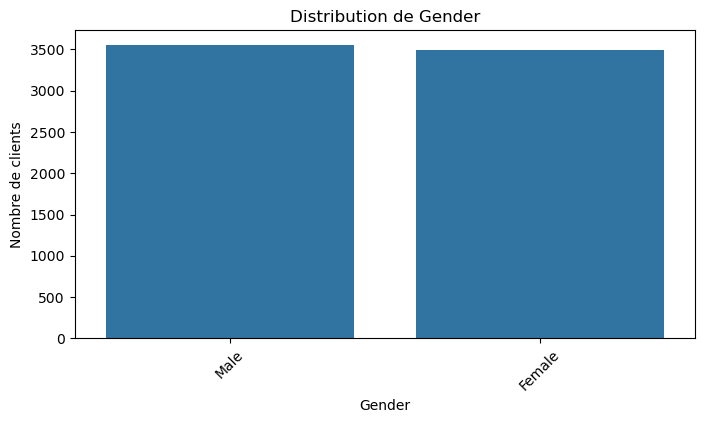

📊 Analyse de la variable : SeniorCitizen

🔢 Nombre de catégories : 2

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
SeniorCitizen,,
No,5901,83.79
Yes,1142,16.21


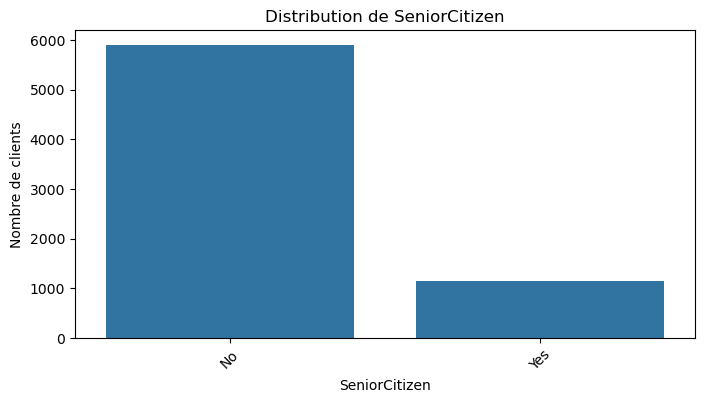

📊 Analyse de la variable : Married

🔢 Nombre de catégories : 2

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
Married,,
No,3641,51.7
Yes,3402,48.3


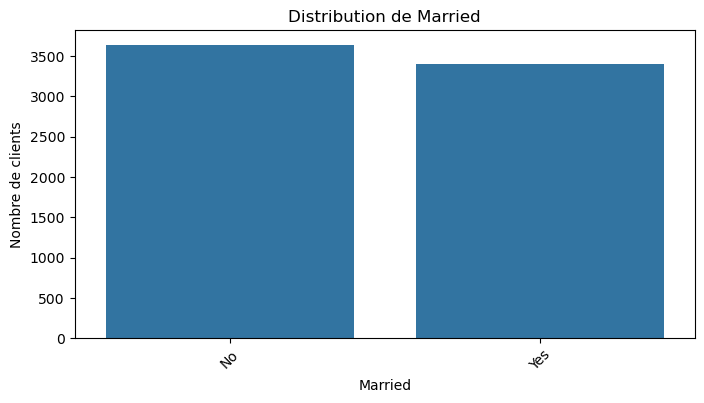

📊 Analyse de la variable : Dependents

🔢 Nombre de catégories : 2

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
Dependents,,
No,5416,76.9
Yes,1627,23.1


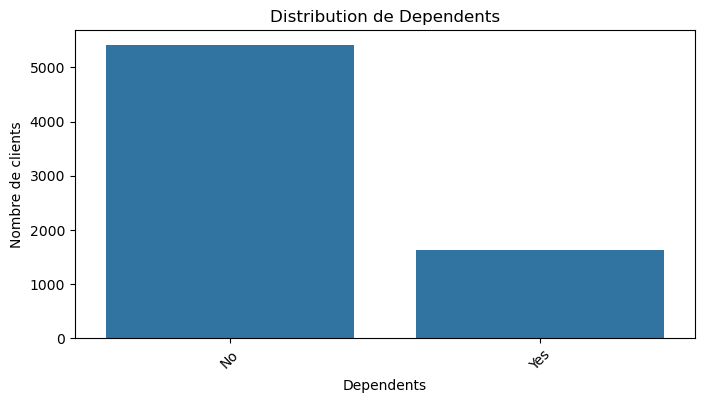

📊 Analyse de la variable : Offer

🔢 Nombre de catégories : 6

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
Offer,,
No Offer,3877,55.05
Offer B,824,11.70
Offer E,805,11.43
Offer D,602,8.55
Offer A,520,7.38
Offer C,415,5.89


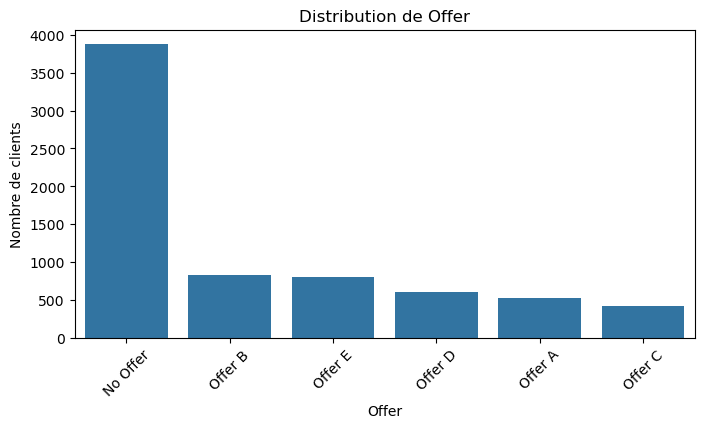

📊 Analyse de la variable : PhoneService

🔢 Nombre de catégories : 2

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
PhoneService,,
Yes,6361,90.32
No,682,9.68


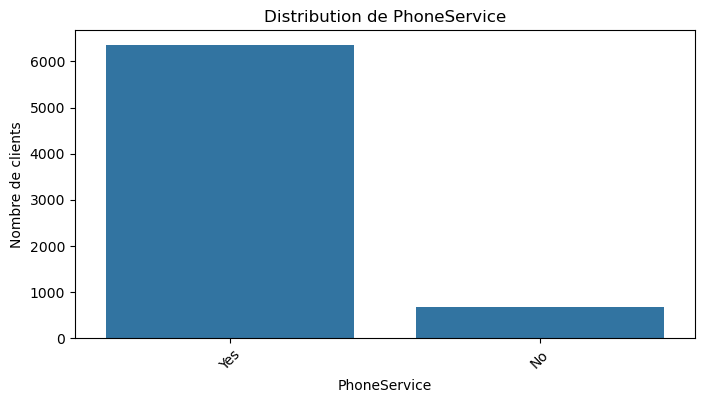

📊 Analyse de la variable : InternetService

🔢 Nombre de catégories : 2

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
InternetService,,
Yes,5517,78.33
No,1526,21.67


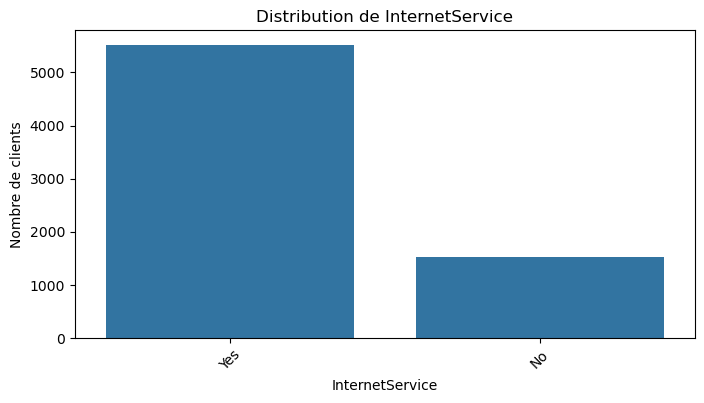

📊 Analyse de la variable : InternetType

🔢 Nombre de catégories : 4

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
InternetType,,
Fiber Optic,3035,43.09
DSL,1652,23.46
No Internet,1526,21.67
Cable,830,11.78


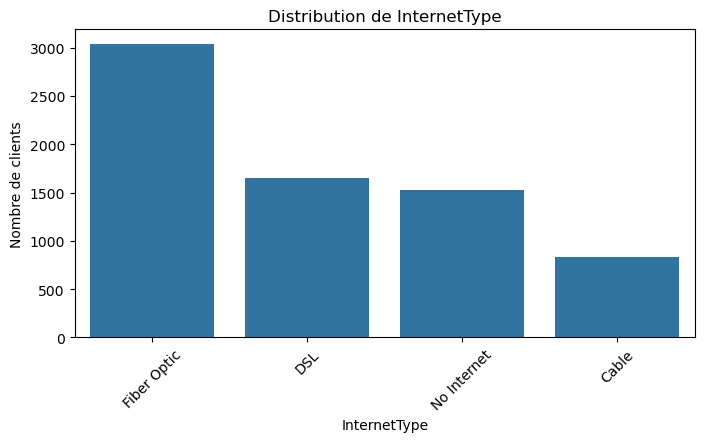

📊 Analyse de la variable : Contract

🔢 Nombre de catégories : 3

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
Contract,,
Month-to-Month,3610,51.26
Two Year,1883,26.74
One Year,1550,22.01


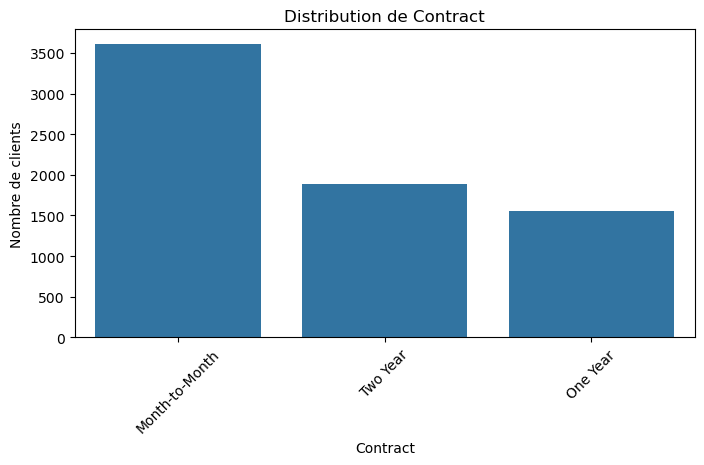

📊 Analyse de la variable : PaymentMethod

🔢 Nombre de catégories : 3

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
PaymentMethod,,
Bank Withdrawal,3909,55.50
Credit Card,2749,39.03
Mailed Check,385,5.47


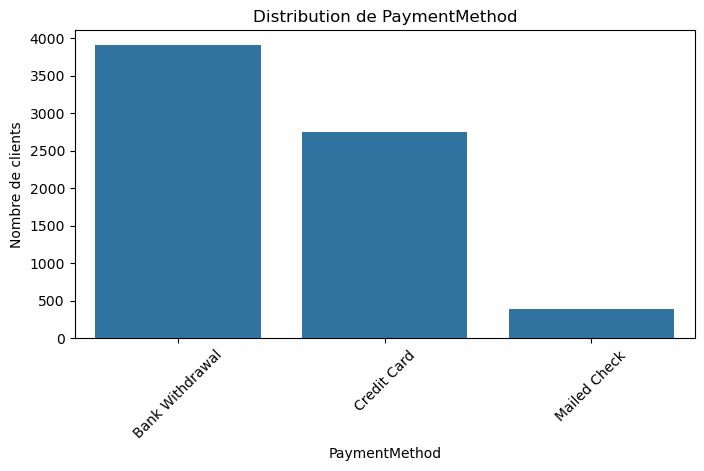

📊 Analyse de la variable : CustomerStatus

🔢 Nombre de catégories : 3

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
CustomerStatus,,
Stayed,4720,67.02
Churned,1869,26.54
Joined,454,6.45


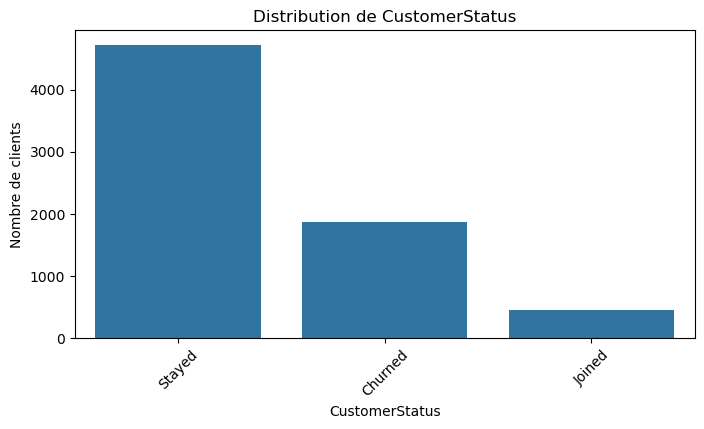

📊 Analyse de la variable : ChurnLabel

🔢 Nombre de catégories : 2

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
ChurnLabel,,
No,5174,73.46
Yes,1869,26.54


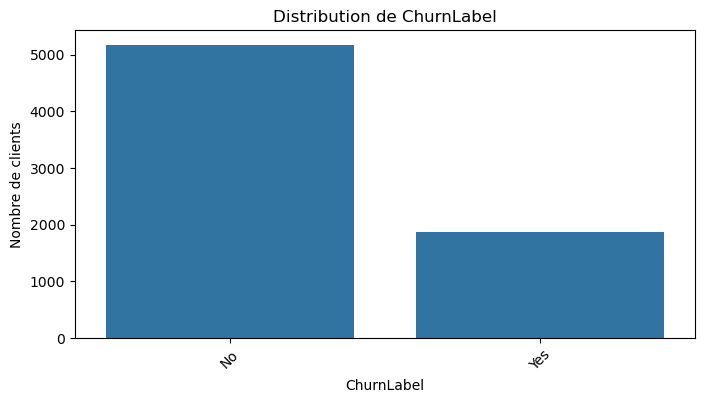

📊 Analyse de la variable : ChurnCategory

🔢 Nombre de catégories : 6

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
ChurnCategory,,
Not Churned,5174,73.46
Competitor,841,11.94
Attitude,314,4.46
Dissatisfaction,303,4.30
Price,211,3.00
Other,200,2.84


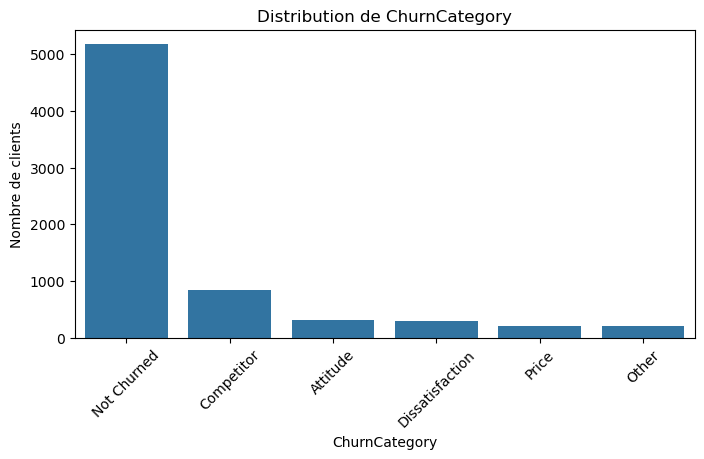

📊 Analyse de la variable : ChurnReason

🔢 Nombre de catégories : 21

📋 Répartition des catégories :


,Nombre de clients,Pourcentage (%)
ChurnReason,,
Not Churned,5174,73.46
Competitor had better devices,313,4.44
Competitor made better offer,311,4.42
Attitude of support person,220,3.12
Don't know,130,1.85
Competitor offered more data,117,1.66
Competitor offered higher download speeds,100,1.42
Attitude of service provider,94,1.33
Price too high,78,1.11


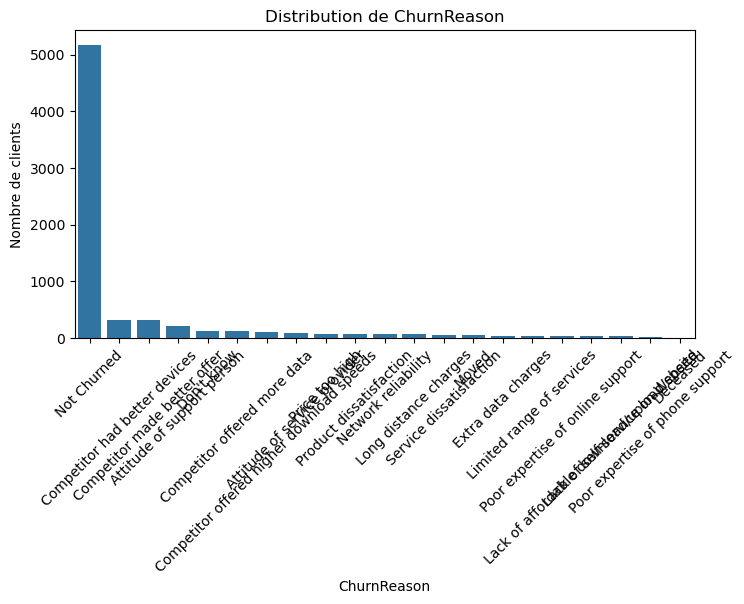

In [16]:
# EDA - Analyse univariée des variables catégorielles

import matplotlib.pyplot as plt
import seaborn as sns


# Sélection des variables catégorielles
categorical_columns = df.select_dtypes(include="object").columns
print("📋 Variables catégorielles analysées :")
display(
    pd.DataFrame(categorical_columns, columns=["Variables catégorielles"])
)


# Fonction d'analyse d'une variable catégorielle
def analyse_variable_categorielle(data, variable):
    print("="*60)
    print(f"📊 Analyse de la variable : {variable}")
    print("="*60)
    # Nombre de catégories
    print("\n🔢 Nombre de catégories :", 
          data[variable].nunique())
    
    # Distribution des catégories
    print("\n📋 Répartition des catégories :")
    distribution = (
        data[variable]
        .value_counts()
        .to_frame(name="Nombre de clients")
    )
    distribution["Pourcentage (%)"] = (
        distribution["Nombre de clients"] 
        / len(data) * 100
    ).round(2)
    display(distribution)

    # Visualisation
    plt.figure(figsize=(8,4))
    sns.countplot(
        data=data,
        x=variable,
        order=data[variable].value_counts().index
    )
    plt.title(f"Distribution de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Nombre de clients")
    plt.xticks(rotation=45)
    plt.show()


# Variables catégorielles importantes
variables_categorielles_importantes = [
    "Gender",
    "SeniorCitizen",
    "Married",
    "Dependents",
    "Offer",
    "PhoneService",
    "InternetService",
    "InternetType",
    "Contract",
    "PaymentMethod",
    "CustomerStatus",
    "ChurnLabel",
    "ChurnCategory",
    "ChurnReason"
]

for var in variables_categorielles_importantes:
    analyse_variable_categorielle(df, var)

📋 Analyse des variables catégorielles avec ChurnLabel

📊 Gender VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
Gender,,
Female,73.08,26.92
Male,73.84,26.16


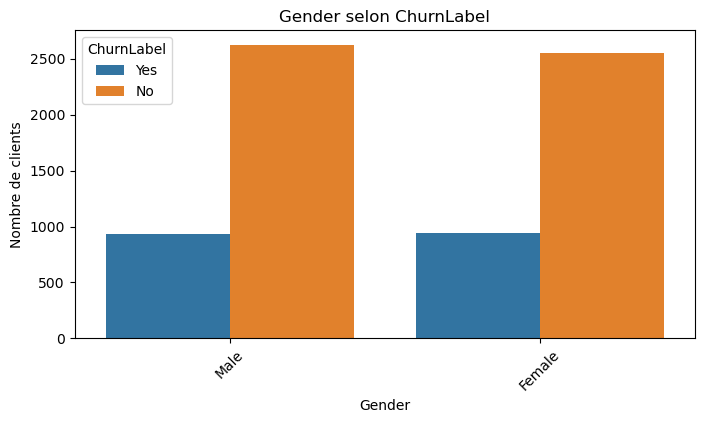


📊 SeniorCitizen VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
SeniorCitizen,,
No,76.39,23.61
Yes,58.32,41.68


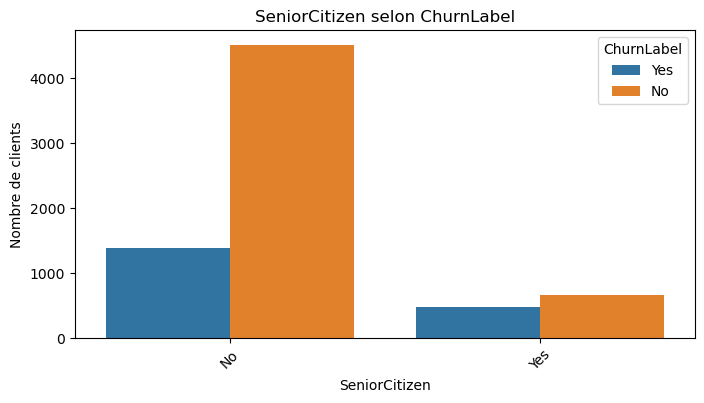


📊 Married VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
Married,,
No,67.04,32.96
Yes,80.34,19.66


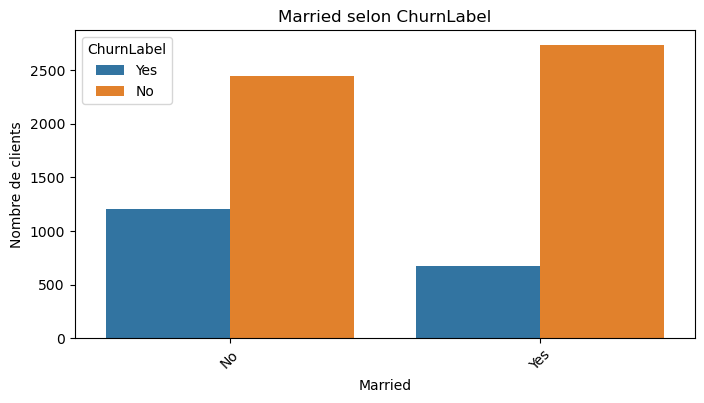


📊 Dependents VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
Dependents,,
No,67.45,32.55
Yes,93.48,6.52


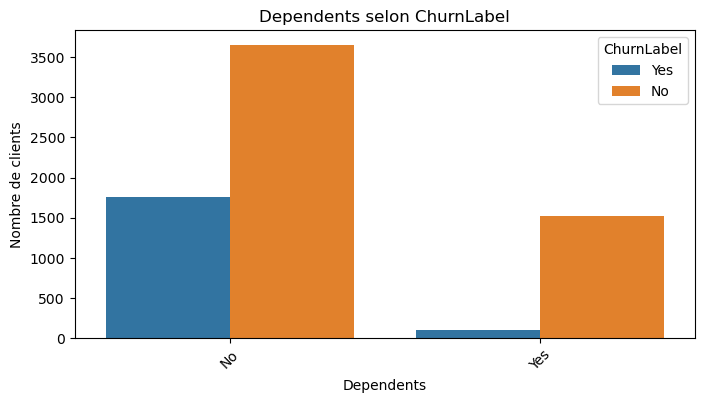


📊 Offer VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
Offer,,
No Offer,72.89,27.11
Offer A,93.27,6.73
Offer B,87.74,12.26
Offer C,77.11,22.89
Offer D,73.26,26.74
Offer E,47.08,52.92


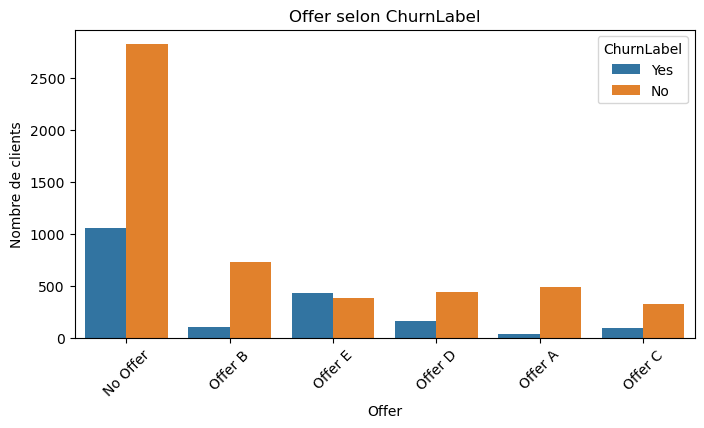


📊 PhoneService VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
PhoneService,,
No,75.07,24.93
Yes,73.29,26.71


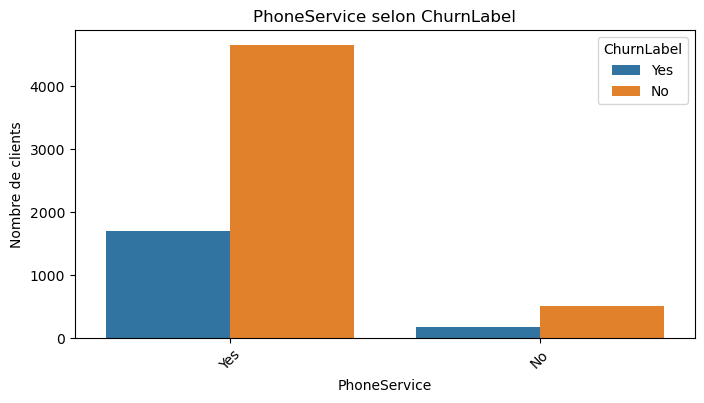


📊 MultipleLines VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
MultipleLines,,
No,74.98,25.02
Yes,71.39,28.61


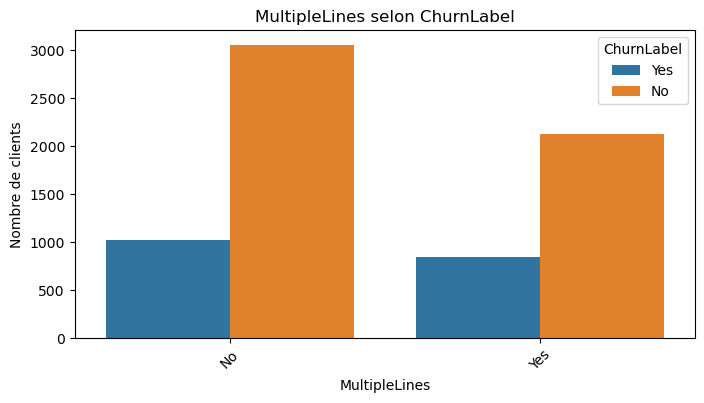


📊 InternetService VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
InternetService,,
No,92.60,7.40
Yes,68.17,31.83


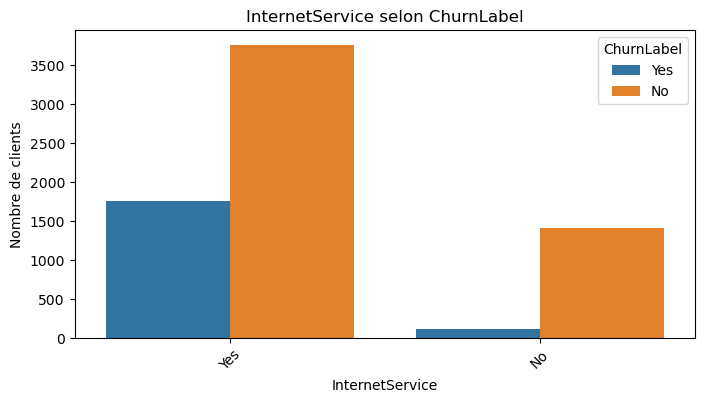


📊 InternetType VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
InternetType,,
Cable,74.34,25.66
DSL,81.42,18.58
Fiber Optic,59.28,40.72
No Internet,92.60,7.40


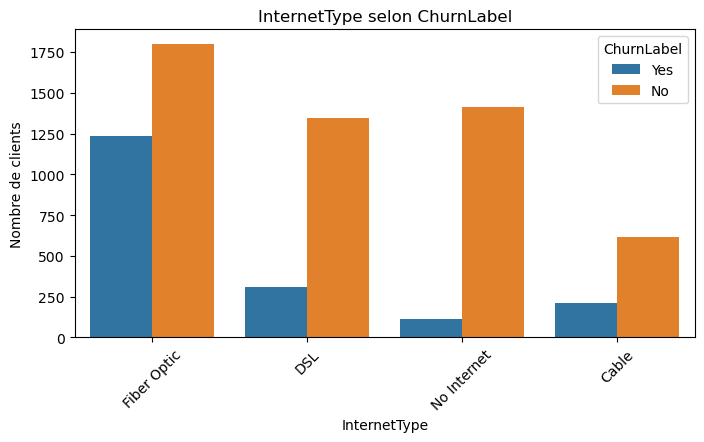


📊 OnlineSecurity VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
OnlineSecurity,,
No,68.67,31.33
Yes,85.39,14.61


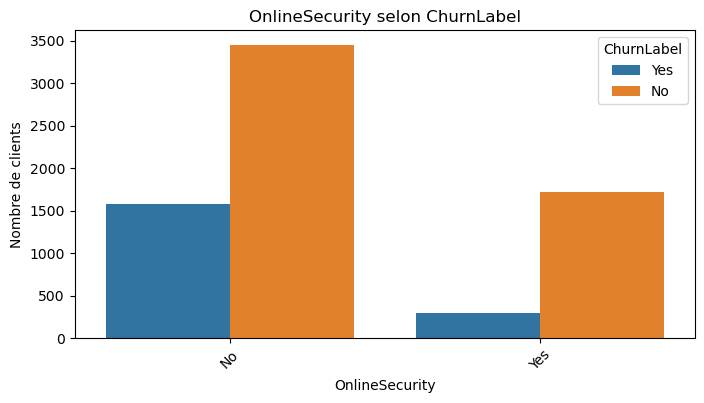


📊 OnlineBackup VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
OnlineBackup,,
No,70.83,29.17
Yes,78.47,21.53


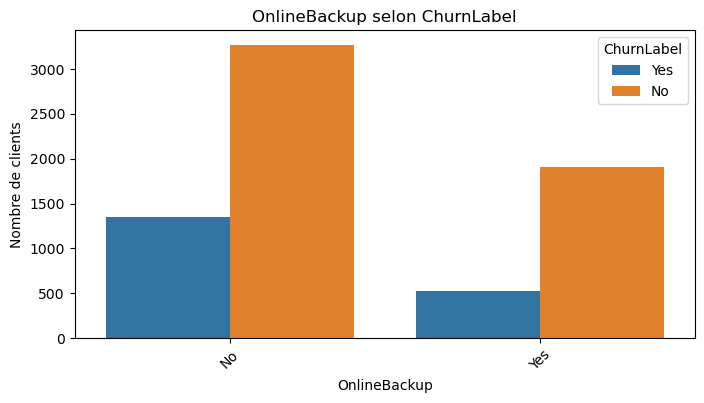


📊 DeviceProtectionPlan VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
DeviceProtectionPlan,,
No,71.35,28.65
Yes,77.50,22.50


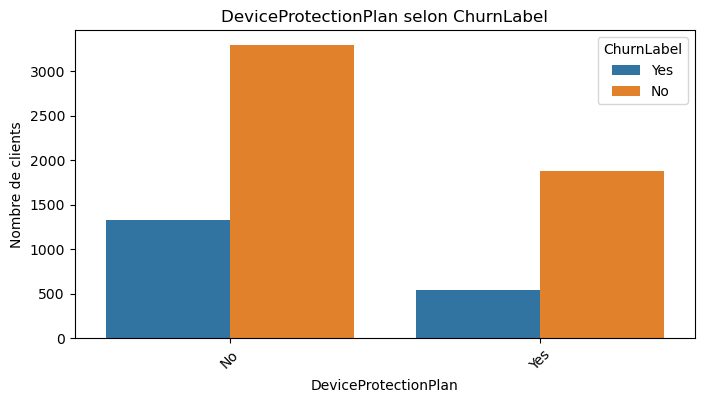


📊 PremiumTechSupport VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
PremiumTechSupport,,
No,68.81,31.19
Yes,84.83,15.17


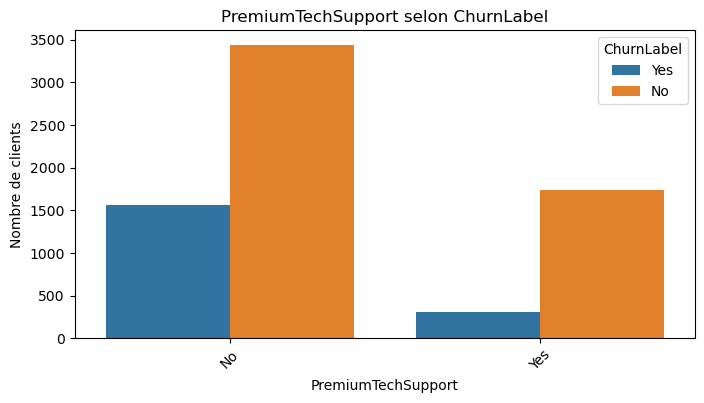


📊 StreamingTV VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
StreamingTV,,
No,75.67,24.33
Yes,69.93,30.07


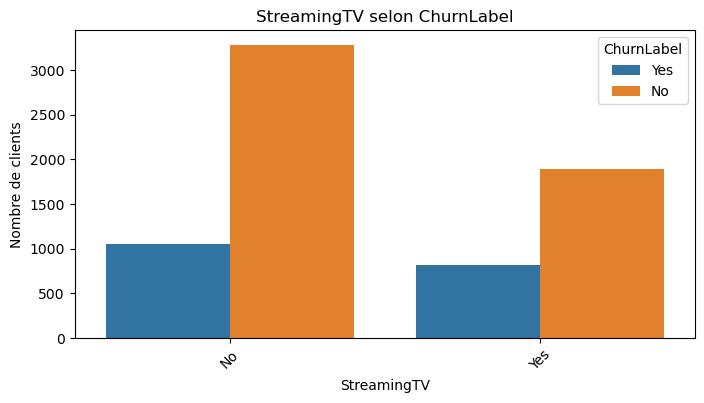


📊 StreamingMovies VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
StreamingMovies,,
No,75.62,24.38
Yes,70.06,29.94


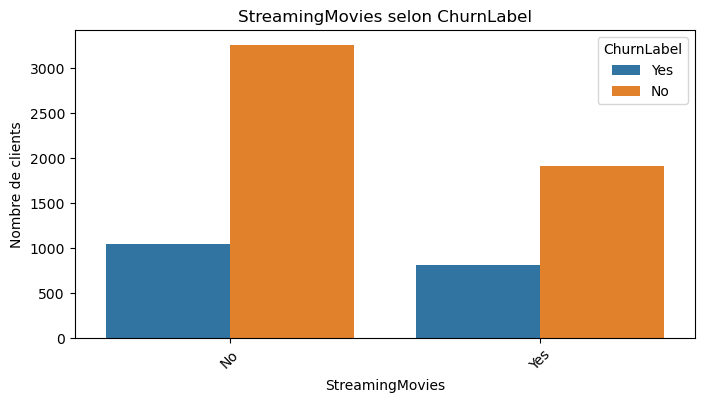


📊 StreamingMusic VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
StreamingMusic,,
No,74.95,25.05
Yes,70.74,29.26


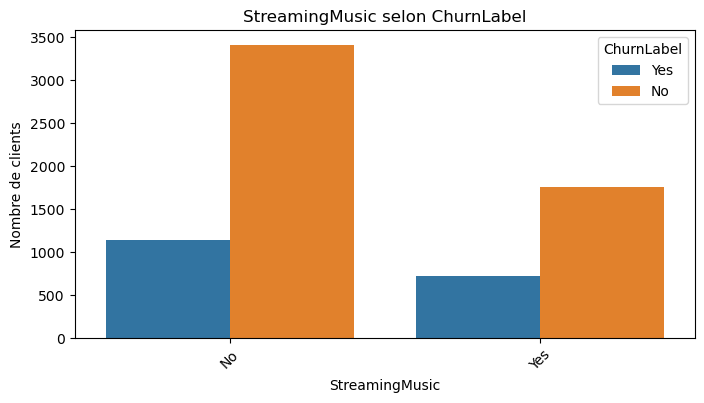


📊 UnlimitedData VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
UnlimitedData,,
No,84.03,15.97
Yes,68.35,31.65


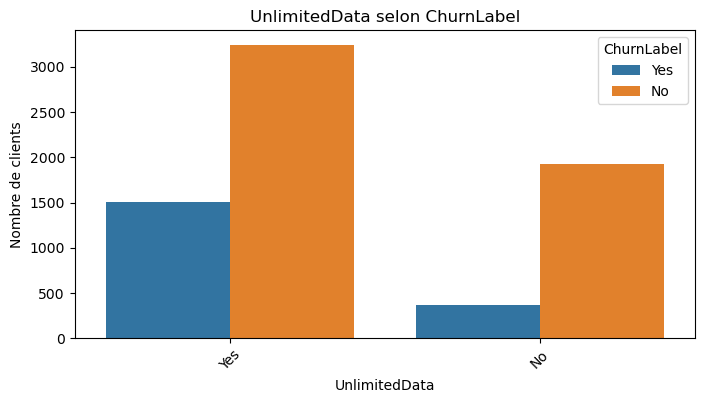


📊 Contract VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
Contract,,
Month-to-Month,54.16,45.84
One Year,89.29,10.71
Two Year,97.45,2.55


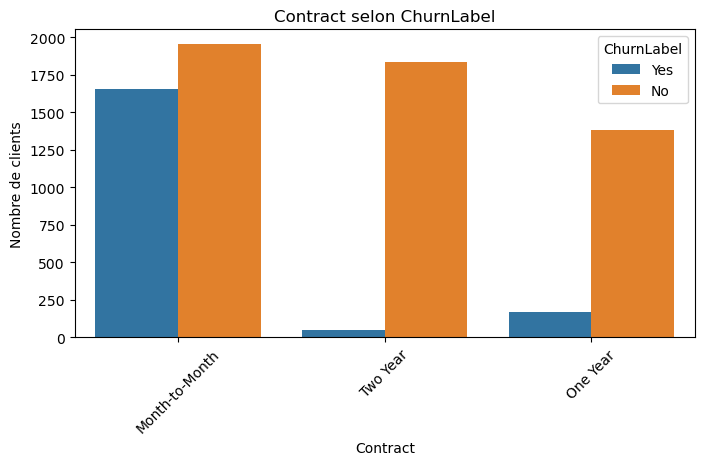


📊 PaperlessBilling VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57


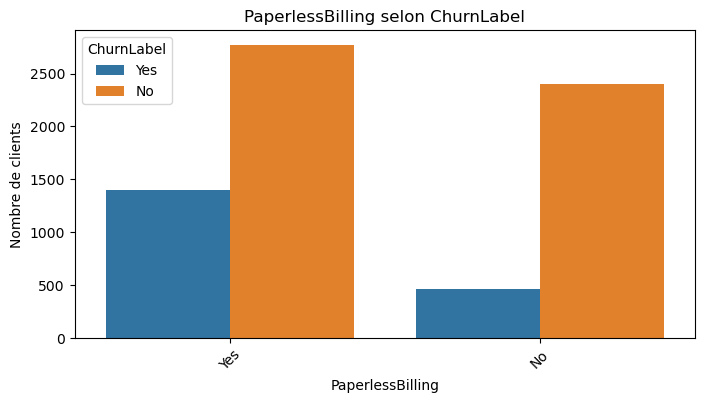


📊 PaymentMethod VS ChurnLabel

📌 Pourcentage de churn par catégorie :


ChurnLabel,No,Yes
PaymentMethod,,
Bank Withdrawal,66.00,34.00
Credit Card,85.52,14.48
Mailed Check,63.12,36.88


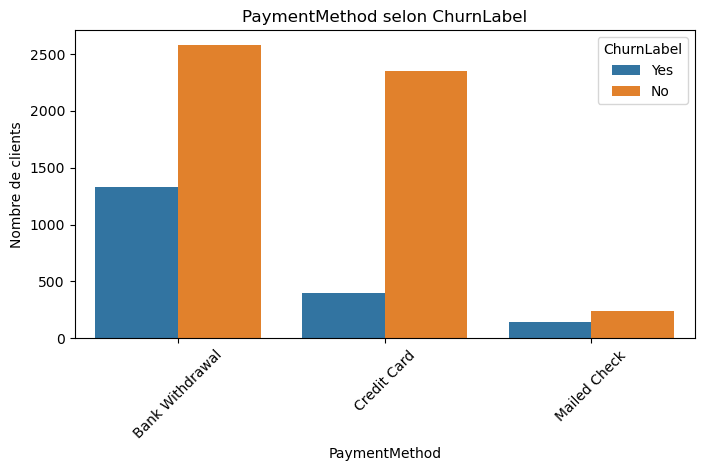



📋 Analyse des variables numériques avec ChurnLabel

📊 Age VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,45.344414
Yes,49.735688


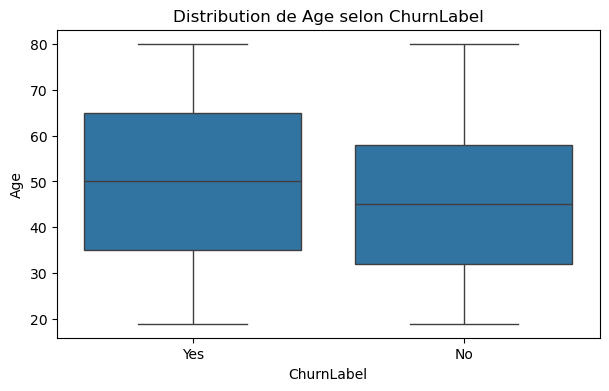


📊 NumberofDependents VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,0.595284
Yes,0.118245


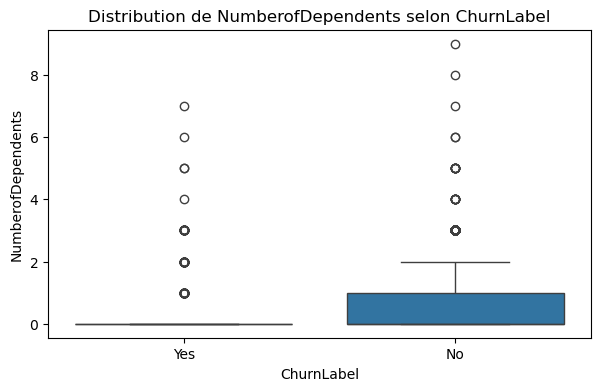


📊 Number_of_Referrals VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,2.468690
Yes,0.521134


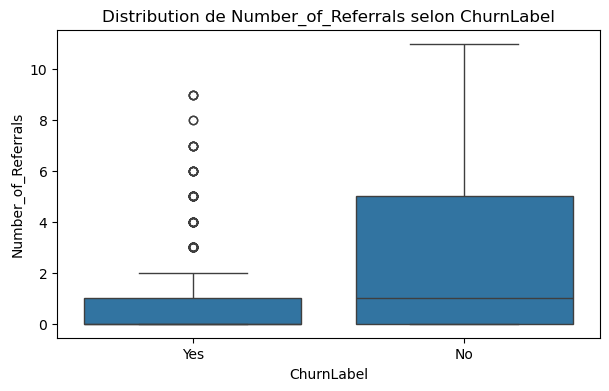


📊 TenureinMonths VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,37.591225
Yes,17.979133


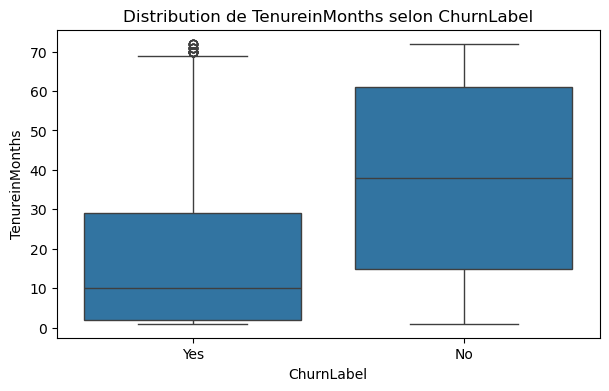


📊 AvgMonthlyLongDistanceCharges VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,22.883572
Yes,23.167635


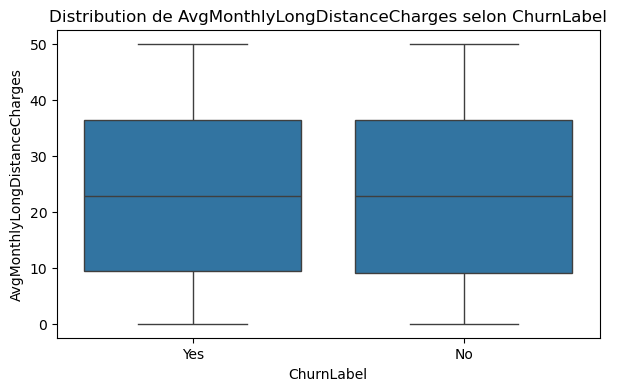


📊 AvgMonthlyGBDownload VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,19.915733
Yes,22.175495


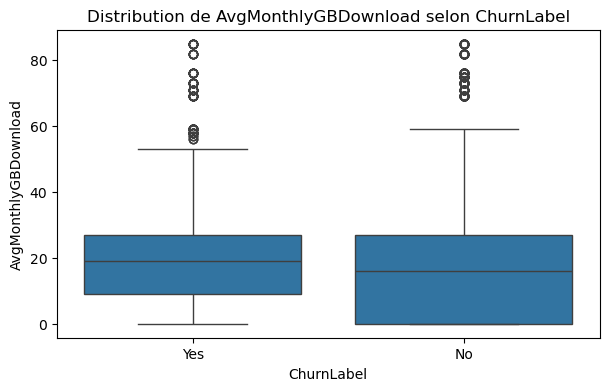


📊 MonthlyCharge VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,61.265124
Yes,74.441332


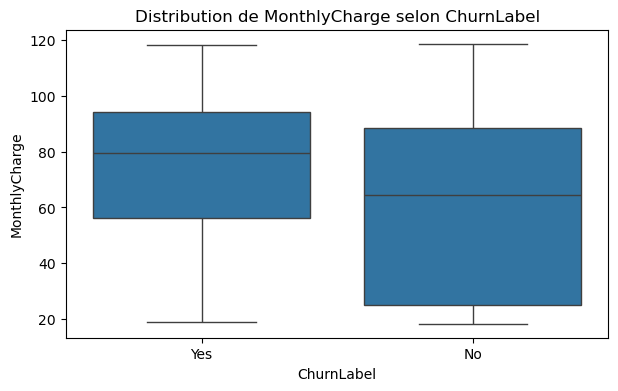


📊 TotalCharges VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,2550.792103
Yes,1531.796094


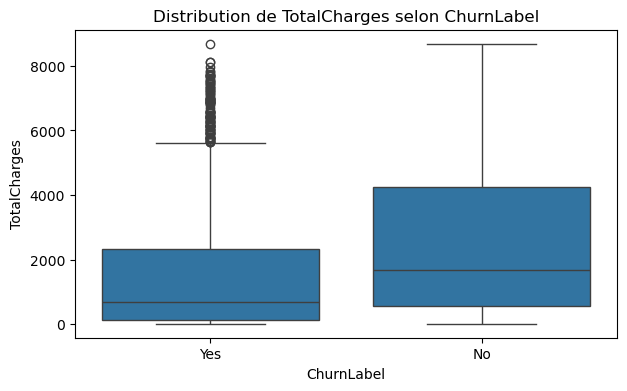


📊 TotalRefunds VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,2.122279
Yes,1.518983


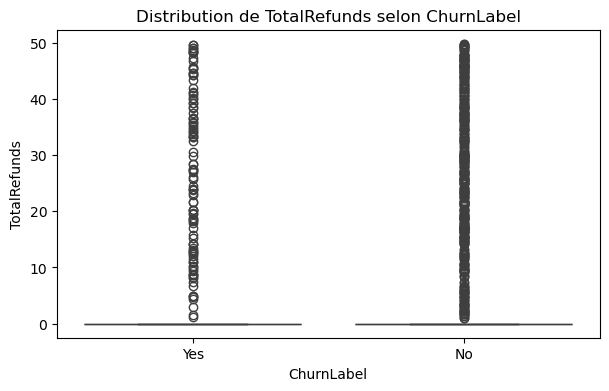


📊 TotalExtraDataCharges VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,6.752996
Yes,7.158909


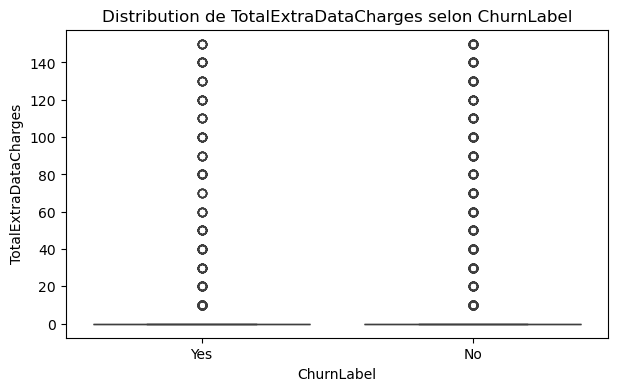


📊 TotalLongDistanceCharges VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,862.952107
Yes,433.917549


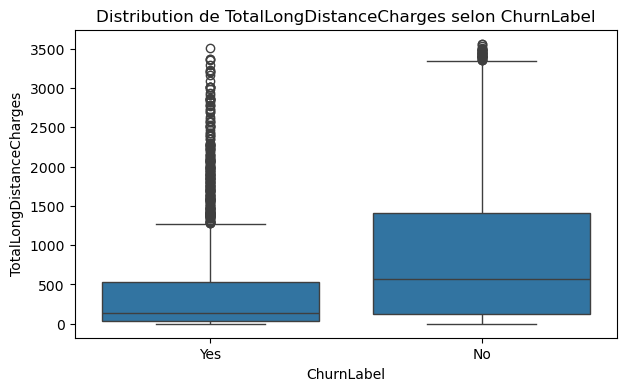


📊 TotalRevenue VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,3418.374927
Yes,1971.353569


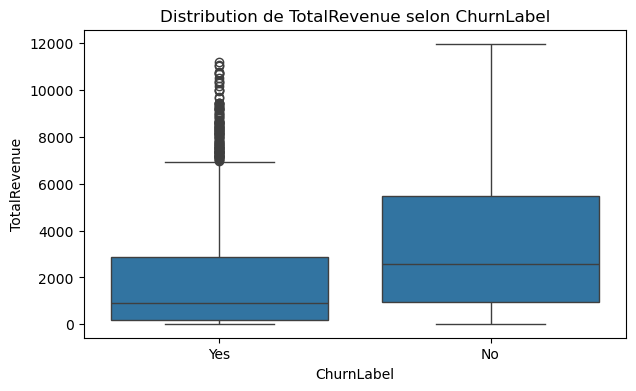


📊 SatisfactionScore VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,3.789911
Yes,1.736223


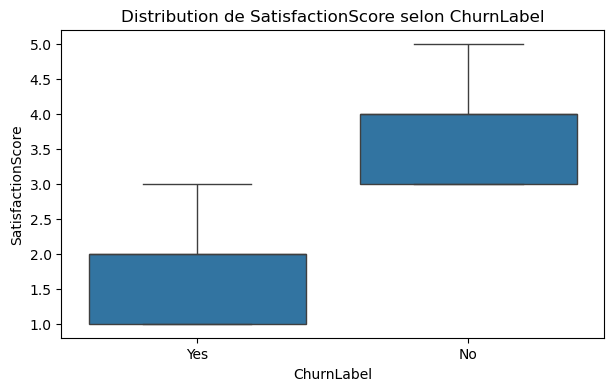


📊 ChurnScore VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,50.098183
Yes,81.777956


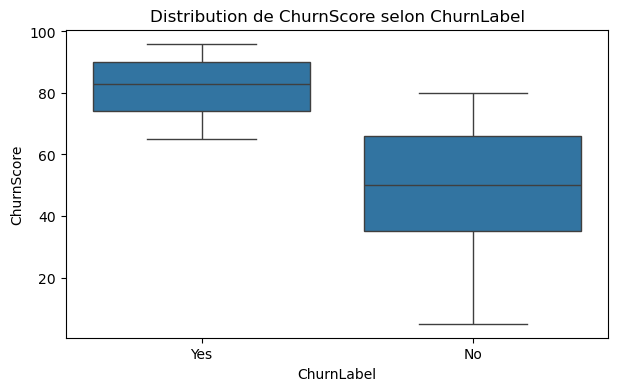


📊 CLTV VS ChurnLabel

📌 Moyenne selon ChurnLabel :


,Moyenne
ChurnLabel,
No,4490.921337
Yes,4149.414660


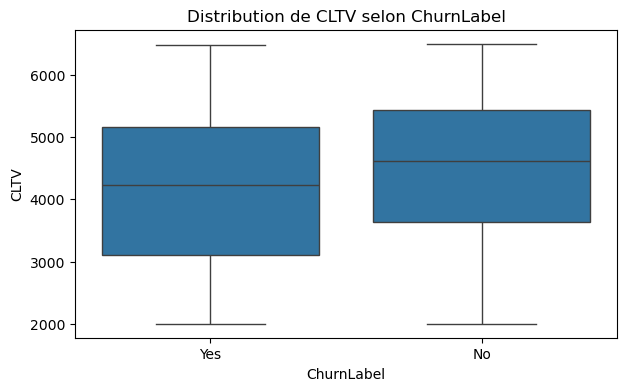



📊 Résumé des variables numériques selon ChurnLabel


ChurnLabel,No,Yes
Age,45.344414,49.735688
NumberofDependents,0.595284,0.118245
Number_of_Referrals,2.468690,0.521134
TenureinMonths,37.591225,17.979133
AvgMonthlyLongDistanceCharges,22.883572,23.167635
AvgMonthlyGBDownload,19.915733,22.175495
MonthlyCharge,61.265124,74.441332
TotalCharges,2550.792103,1531.796094
TotalRefunds,2.122279,1.518983
TotalExtraDataCharges,6.752996,7.158909


In [17]:
# EDA BIVARIEE : Analyse des relations avec ChurnLabel


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) VARIABLES CATEGORIELLES VS ChurnLabel

print("📋 Analyse des variables catégorielles avec ChurnLabel")

# Sélection des variables catégorielles importantes
categorical_features = [

    "Gender",
    "SeniorCitizen",
    "Married",
    "Dependents",
    "Offer",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "InternetType",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtectionPlan",
    "PremiumTechSupport",
    "StreamingTV",
    "StreamingMovies",
    "StreamingMusic",
    "UnlimitedData",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"

]



# Fonction analyse catégorielle
def analyse_categorielle_churn(df, variable):


    print("\n" + "="*70)
    print(f"📊 {variable} VS ChurnLabel")
    print("="*70)



    # Tableau des proportions

    churn_percentage = pd.crosstab(
        df[variable],
        df["ChurnLabel"],
        normalize="index"
    ) * 100



    print("\n📌 Pourcentage de churn par catégorie :")

    display(
        churn_percentage.round(2)
    )



    # Graphique

    plt.figure(figsize=(8,4))


    sns.countplot(
        data=df,
        x=variable,
        hue="ChurnLabel",
        order=df[variable].value_counts().index
    )


    plt.title(
        f"{variable} selon ChurnLabel"
    )

    plt.xlabel(variable)

    plt.ylabel("Nombre de clients")

    plt.xticks(rotation=45)

    plt.show()





# Application sur toutes les variables catégorielles

for variable in categorical_features:

    analyse_categorielle_churn(df, variable)



# 2) VARIABLES NUMERIQUES VS ChurnLabel



print("\n\n📋 Analyse des variables numériques avec ChurnLabel")



numeric_features = [

    "Age",
    "NumberofDependents",
    "Number_of_Referrals",
    "TenureinMonths",
    "AvgMonthlyLongDistanceCharges",
    "AvgMonthlyGBDownload",
    "MonthlyCharge",
    "TotalCharges",
    "TotalRefunds",
    "TotalExtraDataCharges",
    "TotalLongDistanceCharges",
    "TotalRevenue",
    "SatisfactionScore",
    "ChurnScore",
    "CLTV"

]



# Fonction analyse numérique

def analyse_numerique_churn(df, variable):


    print("\n" + "="*70)
    print(f"📊 {variable} VS ChurnLabel")
    print("="*70)



    # Moyenne selon le churn

    print("\n📌 Moyenne selon ChurnLabel :")


    display(

        df.groupby("ChurnLabel")[variable]
        .mean()
        .to_frame(name="Moyenne")

    )



    # Boxplot

    plt.figure(figsize=(7,4))


    sns.boxplot(
        data=df,
        x="ChurnLabel",
        y=variable
    )


    plt.title(
        f"Distribution de {variable} selon ChurnLabel"
    )

    plt.xlabel("ChurnLabel")

    plt.ylabel(variable)


    plt.show()





# Application sur toutes les variables numériques

for variable in numeric_features:

    analyse_numerique_churn(df, variable)




# 3) Résumé global des variables numériques selon Churn



print("\n\n📊 Résumé des variables numériques selon ChurnLabel")


summary_churn = (

    df.groupby("ChurnLabel")[numeric_features]
    .mean()
    .T

)


display(summary_churn)



📊 Variables numériques analysées :


,Variables numériques
0,Age
1,NumberofDependents
2,Number_of_Referrals
3,TenureinMonths
4,AvgMonthlyLongDistanceCharges
5,AvgMonthlyGBDownload
6,MonthlyCharge
7,TotalCharges
8,TotalRefunds
9,TotalExtraDataCharges



📈 Matrice de corrélation :


,Age,NumberofDependents,Number_of_Referrals,TenureinMonths,AvgMonthlyLongDistanceCharges,AvgMonthlyGBDownload,MonthlyCharge,TotalCharges,TotalRefunds,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,ChurnScore,CLTV
Age,1.000000,-0.119000,-0.025141,0.009927,-0.011749,-0.376595,0.144685,0.059684,0.024168,0.025036,0.003065,0.048265,-0.085170,0.083919,-0.001826
NumberofDependents,-0.119000,1.000000,0.278003,0.108237,-0.007324,0.129966,-0.131837,0.022535,0.014023,-0.014436,0.068966,0.038038,0.152873,-0.160743,0.049611
Number_of_Referrals,-0.025141,0.278003,1.000000,0.326975,0.006336,0.038575,0.028173,0.250378,0.024756,0.000350,0.216190,0.261853,0.188926,-0.202209,0.122843
TenureinMonths,0.009927,0.108237,0.326975,1.000000,0.014596,0.049119,0.247582,0.826074,0.059021,0.082266,0.674149,0.853146,0.210557,-0.224982,0.396292
AvgMonthlyLongDistanceCharges,-0.011749,-0.007324,0.006336,0.014596,1.000000,-0.030455,0.138396,0.069500,-0.018644,0.002414,0.599828,0.232291,0.001146,0.021857,0.023858
AvgMonthlyGBDownload,-0.376595,0.129966,0.038575,0.049119,-0.030455,1.000000,0.391787,0.223268,0.002397,0.088939,0.011373,0.180726,-0.091657,0.022421,0.023043
MonthlyCharge,0.144685,-0.131837,0.028173,0.247582,0.138396,0.391787,1.000000,0.651236,0.033482,0.126244,0.246300,0.588887,-0.223922,0.132115,0.098693
TotalCharges,0.059684,0.022535,0.250378,0.826074,0.069500,0.223268,0.651236,1.000000,0.039558,0.121859,0.610185,0.972212,0.068950,-0.123961,0.341947
TotalRefunds,0.024168,0.014023,0.024756,0.059021,-0.018644,0.002397,0.033482,0.039558,1.000000,0.016755,0.028113,0.036984,0.024221,-0.013516,0.007992
TotalExtraDataCharges,0.025036,-0.014436,0.000350,0.082266,0.002414,0.088939,0.126244,0.121859,0.016755,1.000000,0.058871,0.122496,-0.010472,0.008343,0.042540


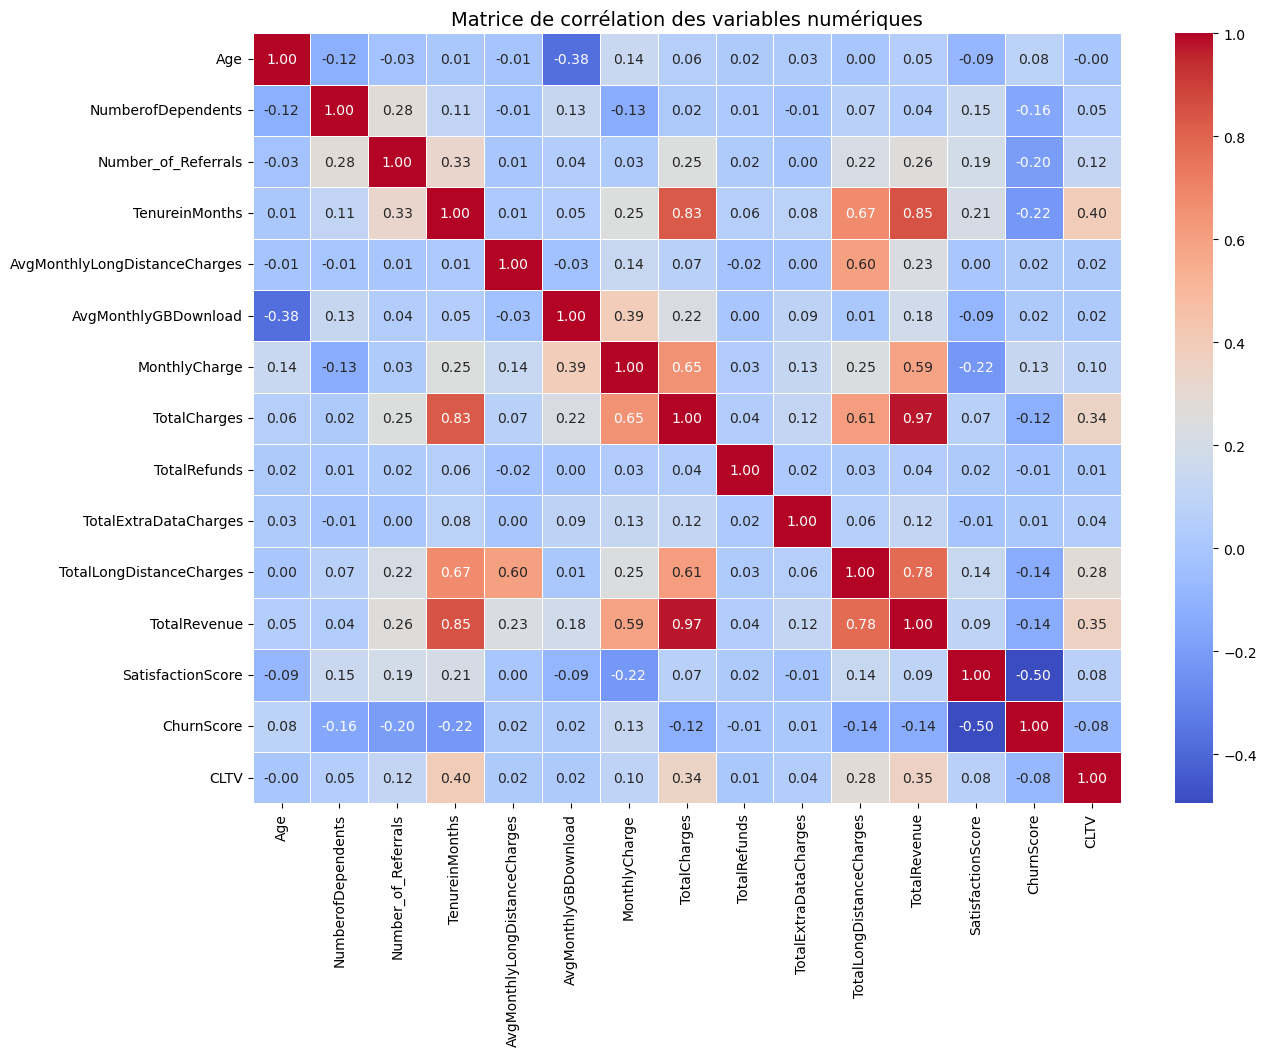


🔎 Relations fortement corrélées :


,Variable 1,Variable 2,Corrélation
116,TotalCharges,TotalRevenue,0.972212
172,TotalRevenue,TotalCharges,0.972212
168,TotalRevenue,TenureinMonths,0.853146
56,TenureinMonths,TotalRevenue,0.853146
108,TotalCharges,TenureinMonths,0.826074
52,TenureinMonths,TotalCharges,0.826074
161,TotalLongDistanceCharges,TotalRevenue,0.778559
175,TotalRevenue,TotalLongDistanceCharges,0.778559



📌 Interprétation :

- Une corrélation proche de +1 indique que deux variables évoluent dans le même sens.
- Une corrélation proche de -1 indique qu'elles évoluent dans des sens opposés.
- Une corrélation proche de 0 indique une faible relation.

Les variables fortement corrélées doivent être analysées avant la modélisation
car elles peuvent contenir une information similaire.



In [18]:
# EDA - Analyse des corrélations numériques

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Sélection des variables numériques
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns


print("📊 Variables numériques analysées :")

display(
    pd.DataFrame(
        numeric_columns,
        columns=["Variables numériques"]
    )
)


# 2) Calcul de la matrice de corrélation

correlation_matrix = df[numeric_columns].corr()


print("\n📈 Matrice de corrélation :")

display(correlation_matrix)



# 3) Visualisation avec une Heatmap

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Matrice de corrélation des variables numériques",
    fontsize=14
)

plt.show()



# 4) Identifier les fortes corrélations

strong_correlations = (
    correlation_matrix
    .unstack()
    .reset_index()
)

strong_correlations.columns = [
    "Variable 1",
    "Variable 2",
    "Corrélation"
]


# Suppression des doublons
strong_correlations = strong_correlations[
    strong_correlations["Variable 1"] != strong_correlations["Variable 2"]
]


# Garder uniquement les relations fortes
strong_correlations = strong_correlations[
    abs(strong_correlations["Corrélation"]) >= 0.7
]


# Trier par importance
strong_correlations = strong_correlations.sort_values(
    by="Corrélation",
    ascending=False
)


print("\n🔎 Relations fortement corrélées :")

display(strong_correlations)



# ------------------------------------------
# 5) Résumé des corrélations importantes
# ------------------------------------------

print("""
📌 Interprétation :

- Une corrélation proche de +1 indique que deux variables évoluent dans le même sens.
- Une corrélation proche de -1 indique qu'elles évoluent dans des sens opposés.
- Une corrélation proche de 0 indique une faible relation.

Les variables fortement corrélées doivent être analysées avant la modélisation
car elles peuvent contenir une information similaire.
""")

In [19]:
df = df.drop(columns=["TotalCharges"])

print("TotalCharges supprimée avec succès.")

# Suppression de TotalCharges :
# Cette variable présente une très forte corrélation avec TotalRevenue (r = 0.972),
# indiquant une forte redondance d'information entre les deux variables.
# TotalRevenue est conservée comme indicateur global de la valeur financière du client.

TotalCharges supprimée avec succès.


In [20]:
# Enregistrer le dataset nettoyé
df.to_csv("TelcoCustomerChurn_Clean.csv", index=False)

print("Dataset nettoyé enregistré avec succès ✅")

Dataset nettoyé enregistré avec succès ✅


In [21]:
import shutil

source = r"C:\Users\dell\Project\TelcoCustomerChurn_Clean.csv"
destination = r"C:\Users\dell\Desktop\TelcoCustomerChurn_Clean.csv"

shutil.copy(source, destination)

print("Fichier copié sur le Bureau avec succès ✅")

Fichier copié sur le Bureau avec succès ✅
